In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
# %pip uninstall -y numpy
# %pip install -q numpy==1.26.4
# %pip install --upgrade scipy scikit-learn threadpoolctl
# %pip install gpflow==2.9.2

In [2]:
import numpy as np
# from sklearn.calibration import LabelEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.discriminant_analysis import StandardScaler
from sklearn.metrics import classification_report
import pandas as pd
from datetime import datetime
import gpflow
import tensorflow as tf
import warnings
from prettytable import PrettyTable
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import trange,tqdm
from sklearn.metrics import accuracy_score
warnings.filterwarnings('ignore')

def print_table(df: pd.DataFrame):
    top_rows = df.copy()
    table = PrettyTable()
    table.field_names = top_rows.columns.tolist()
    for _, row in top_rows.iterrows():
        table.add_row(row.tolist())
    print(table)

In [3]:
df_audit_grade = pd.read_parquet(r'H:\My Drive\Projects_mdw\BayesAudit\Data\audit_grading.parquet')
# df_audit_grade = pd.read_parquet(r'/content/drive/MyDrive/Projects_mdw/BayesAudit/Data/audit_grading.parquet')
print(df_audit_grade.shape)
print(df_audit_grade.columns)
df_audit_grade.head()

(413, 3)
Index(['Site_ID', 'Shop Grade', 'Current Audit Date'], dtype='object')


,Site_ID,Shop Grade,Current Audit Date
0,S001,B,2025-09-11
1,S002,C-,2025-08-11
2,S003,B,2025-05-14
3,S004,A,2025-07-09
4,S005,B,2025-02-06


In [4]:
df_dim_store = df_audit_grade[['Site_ID']]
df_dim_store.drop_duplicates(inplace=True)
print(df_dim_store.shape)
df_dim_store.head()

(413, 1)


,Site_ID
0,S001
1,S002
2,S003
3,S004
4,S005


### Preprocess Audit Grades Data

In [5]:
df_audit_grade['Current Audit Date'] = pd.to_datetime(df_audit_grade['Current Audit Date'])

current_date = df_audit_grade['Current Audit Date'].max()
days_count =  60 # current_date.day + 31 #+30

df_audit_grade = df_audit_grade[(current_date - df_audit_grade['Current Audit Date']).dt.days <= days_count]
print('df_audit_grade shape :',df_audit_grade.shape)
print('df_audit_grade Min date :',df_audit_grade['Current Audit Date'].min())
print('df_audit_grade Max date :',df_audit_grade['Current Audit Date'].max())

df_audit_grade shape : (116, 3)
df_audit_grade Min date : 2025-08-25 00:00:00
df_audit_grade Max date : 2025-10-24 00:00:00


In [6]:
# df_kpi_score = pd.read_parquet(r'/content/drive/MyDrive/Projects_mdw/BayesAudit/Data/kpi_scores.parquet')
df_kpi_score = pd.read_parquet(r'H:\My Drive\Projects_mdw\BayesAudit\Data\kpi_scores.parquet')
print(df_kpi_score.shape)
print(df_kpi_score.columns)
df_kpi_score.head()

(58013, 24)
Index(['EDATE', 'INVENTORY_TURNOVER_RTO_RISK_SCORE',
       'PRODUCTRELEASE_COST_RTO_RISK_SCORE',
       'BLACKLIST_CUST_ACTIVE_ACC_RISK_SCORE', 'PH_NO_CHANGE_CUST_RISK_SCORE',
       'EARL_CLOS_DISCOUNT_RISK_SCORE', 'HIRE_SALE_ASS_ACC_RISK_SCORE',
       'CASHA_RISK_SCORE', 'ACC_LESS_ADD_PAY_RISK_SCORE',
       'ISSUE_RTO_RISK_SCORE', 'cash_coll_vs_banking_rto',
       'UNSALEABLE_INVENTORY_RTO', 'REVERT_INVENTORY_RTO',
       'TOT_UNPAID_CASH_SALES_RISK', 'TOT_HP_ARREARS_RISK_RTO',
       'TOT_CRDT_OUTSTN_AMT_DUE_DAYS_RLN', 'RETURN_CHEQUE_RISK_SCORE',
       'SPECIAL_DISCOUNT_RISK_SCORE', 'MULTI_HP_ACC_PER_CUST_RISK_SCORE',
       'INITIAL_PAYMENT_NOT_PAID_RISK_SCORE', 'SALES_RETURN_RISK_SCORE',
       'PRODUCT_MANUAL_ORDERS_RISK_SCORE', 'SHORT_REMIT_RISK_SCORE',
       'Site_ID'],
      dtype='object')


,EDATE,INVENTORY_TURNOVER_RTO_RISK_SCORE,PRODUCTRELEASE_COST_RTO_RISK_SCORE,BLACKLIST_CUST_ACTIVE_ACC_RISK_SCORE,PH_NO_CHANGE_CUST_RISK_SCORE,EARL_CLOS_DISCOUNT_RISK_SCORE,HIRE_SALE_ASS_ACC_RISK_SCORE,CASHA_RISK_SCORE,ACC_LESS_ADD_PAY_RISK_SCORE,ISSUE_RTO_RISK_SCORE,...,TOT_HP_ARREARS_RISK_RTO,TOT_CRDT_OUTSTN_AMT_DUE_DAYS_RLN,RETURN_CHEQUE_RISK_SCORE,SPECIAL_DISCOUNT_RISK_SCORE,MULTI_HP_ACC_PER_CUST_RISK_SCORE,INITIAL_PAYMENT_NOT_PAID_RISK_SCORE,SALES_RETURN_RISK_SCORE,PRODUCT_MANUAL_ORDERS_RISK_SCORE,SHORT_REMIT_RISK_SCORE,Site_ID
0,2025-09-20,0.842112,0.500000,0.013710,0.014951,0.000000,0.000000,0.145757,NaN,0.0,...,0.018022,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S254
1,2025-09-20,0.825651,0.430075,0.000000,0.499210,0.000000,0.000000,0.091817,NaN,0.0,...,0.047599,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S013
2,2025-09-20,0.857242,0.406463,0.000000,0.210004,0.241084,0.688894,0.414772,NaN,0.0,...,0.013334,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S467
3,2025-09-20,0.323289,0.413312,0.005499,0.020825,0.000000,0.863735,0.708144,NaN,0.0,...,0.084018,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S231
4,2025-09-20,0.821366,0.412756,0.003485,0.400223,0.272825,0.000000,0.833605,NaN,0.0,...,0.025874,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S478


### Preprocess KPI Scores Data

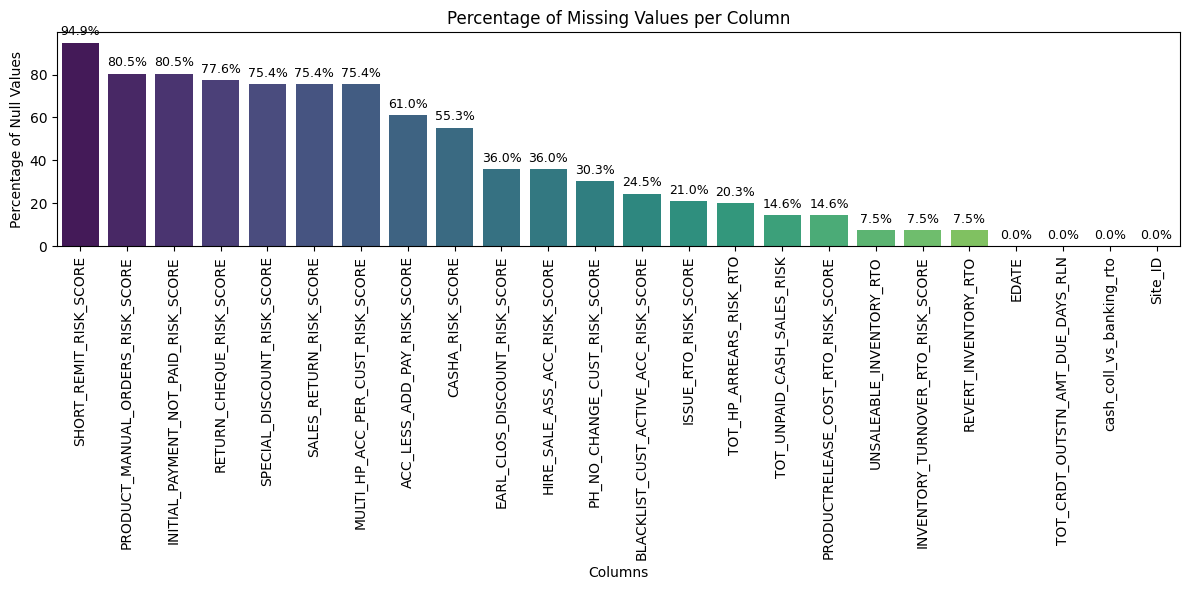

In [7]:
df_kpi_score['EDATE'] = pd.to_datetime(df_kpi_score['EDATE'])
null_df_kpi_score = pd.DataFrame(df_kpi_score.isnull().sum(),columns=['Null_Count'])
null_df_kpi_score['Null_Count'] = (null_df_kpi_score['Null_Count'] / df_kpi_score.shape[0])*100
null_df_kpi_score=null_df_kpi_score.sort_values(by='Null_Count',ascending=False)
# null_df_kpi_score.head(null_df_kpi_score.shape[0])

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=null_df_kpi_score.index,
    y=null_df_kpi_score['Null_Count'],
    palette='viridis'
)
plt.xticks(rotation=90)
plt.ylabel('Percentage of Null Values')
plt.xlabel('Columns')
plt.title('Percentage of Missing Values per Column')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9,
        xytext=(0, 3),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()

In [8]:
drop_columns = null_df_kpi_score[null_df_kpi_score['Null_Count']>25].index
print(drop_columns)

df_kpi_score.drop(drop_columns,axis=1,inplace=True)
df_kpi_score.head()

Index(['SHORT_REMIT_RISK_SCORE', 'PRODUCT_MANUAL_ORDERS_RISK_SCORE',
       'INITIAL_PAYMENT_NOT_PAID_RISK_SCORE', 'RETURN_CHEQUE_RISK_SCORE',
       'SPECIAL_DISCOUNT_RISK_SCORE', 'SALES_RETURN_RISK_SCORE',
       'MULTI_HP_ACC_PER_CUST_RISK_SCORE', 'ACC_LESS_ADD_PAY_RISK_SCORE',
       'CASHA_RISK_SCORE', 'EARL_CLOS_DISCOUNT_RISK_SCORE',
       'HIRE_SALE_ASS_ACC_RISK_SCORE', 'PH_NO_CHANGE_CUST_RISK_SCORE'],
      dtype='object')


,EDATE,INVENTORY_TURNOVER_RTO_RISK_SCORE,PRODUCTRELEASE_COST_RTO_RISK_SCORE,BLACKLIST_CUST_ACTIVE_ACC_RISK_SCORE,ISSUE_RTO_RISK_SCORE,cash_coll_vs_banking_rto,UNSALEABLE_INVENTORY_RTO,REVERT_INVENTORY_RTO,TOT_UNPAID_CASH_SALES_RISK,TOT_HP_ARREARS_RISK_RTO,TOT_CRDT_OUTSTN_AMT_DUE_DAYS_RLN,Site_ID
0,2025-09-20,0.842112,0.500000,0.013710,0.0,0.0,0.043791,0.047997,0.000000,0.018022,0.0,S254
1,2025-09-20,0.825651,0.430075,0.000000,0.0,0.0,0.016666,0.026522,0.047185,0.047599,0.0,S013
2,2025-09-20,0.857242,0.406463,0.000000,0.0,0.0,0.005226,0.037853,0.000000,0.013334,0.0,S467
3,2025-09-20,0.323289,0.413312,0.005499,0.0,0.0,0.019839,0.092460,0.000000,0.084018,0.0,S231
4,2025-09-20,0.821366,0.412756,0.003485,0.0,0.0,0.001064,0.046433,0.102690,0.025874,0.0,S478


### Feature Builder (Dynamic Window)

In [9]:
def build_feature_df(window_size):
    feature_df = []
    sites = df_dim_store['Site_ID'].unique()

    for site in sites:
        try:
            audit_row = df_audit_grade[df_audit_grade['Site_ID'] == site].iloc[0]
            audit_date = audit_row['Current Audit Date'].date()
            audit_grade = audit_row['Shop Grade']
        except:
            audit_date = df_kpi_score['EDATE'].max().date()
            audit_grade = None

        sub = df_kpi_score[
            (df_kpi_score['Site_ID'] == site) &
            (df_kpi_score['EDATE'].dt.date <= audit_date)
        ].sort_values(by='EDATE', ascending=False).reset_index(drop=True)

        if len(sub) < window_size:
            continue

        for i in range(window_size):
            row = {
                'branch': site,
                'grade': audit_grade,
                'day': i + 1,
                'rundate': sub.loc[i, 'EDATE']
            }

            for col in sub.columns:
                if col not in ['Site_ID', 'EDATE']:
                    row[col] = sub.loc[i, col]

            feature_df.append(row)

    return pd.DataFrame(feature_df)

def build_input_matrix(df, feature_cols):
    times = df['day'].values.reshape(-1, 1)
    feats = df[feature_cols].values
    return np.hstack([times, feats]).astype(np.float64)

In [10]:
def train_svgp(X, Y, num_classes):

    kernel = gpflow.kernels.RBF() * gpflow.kernels.Linear()

    num_inducing = min(100, len(X))
    Z = KMeans(n_clusters=num_inducing, random_state=0).fit(X).cluster_centers_

    model = gpflow.models.SVGP(
        kernel=kernel,
        likelihood=gpflow.likelihoods.MultiClass(num_classes=num_classes),
        inducing_variable=Z,
        num_latent_gps=num_classes,
        whiten=True
    )

    def objective():
        return -model.elbo((X, Y))

    opt = tf.optimizers.Adam(0.01)

    for step in range(500):
        with tf.GradientTape() as tape:
            loss = objective()
        grads = tape.gradient(loss, model.trainable_variables)
        opt.apply_gradients(zip(grads, model.trainable_variables))

    return model

# Prediction + Confidence + Entropy
def predict_with_uncertainty(model, df, feature_cols, scaler_time, scaler_feats, grades):

    results = []

    for branch in df['branch'].unique():

        df_b = df[df['branch'] == branch]

        X_test = build_input_matrix(df_b, feature_cols)

        X_test[:, 0] = scaler_time.transform(X_test[:, 0].reshape(-1,1)).flatten()
        X_test[:, 1:] = scaler_feats.transform(X_test[:, 1:])

        prob_mean, _ = model.predict_y(X_test)
        prob = prob_mean.numpy().mean(axis=0)

        pred_class = np.argmax(prob)
        pred_grade = grades[pred_class]

        confidence = np.max(prob)

        entropy = -np.sum(prob * np.log(prob + 1e-9))

        results.append({
            'branch': branch,
            'pred_grade': pred_grade,
            'confidence': confidence,
            'entropy': entropy
        })

    return pd.DataFrame(results)

# Semi-Supervised Experiment
def run_semi_supervised_experiment(window_size):

    print(f"\n===== Semi-Supervised ({window_size} days) =====")

    feature_df = build_feature_df(window_size)

    graded_df = feature_df.dropna(subset=['grade']).copy()
    ungraded_df = feature_df[feature_df['grade'].isna()].copy()

    graded_df.fillna(0, inplace=True)
    ungraded_df.fillna(0, inplace=True)

    # Encode
    le = LabelEncoder()
    y = le.fit_transform(graded_df['grade'])
    grades = le.classes_

    feature_cols = list(
        feature_df.drop(columns=['branch','grade','day','rundate']).columns
    )

    # Build X
    X = build_input_matrix(graded_df, feature_cols)
    Y = y.reshape(-1,1)

    scaler_time = StandardScaler()
    scaler_feats = StandardScaler()

    X[:, 0] = scaler_time.fit_transform(X[:, 0].reshape(-1,1)).flatten()
    X[:, 1:] = scaler_feats.fit_transform(X[:, 1:])

    # BASELINE MODEL
    base_model = train_svgp(X, Y, len(grades))

    # Evaluate baseline
    base_preds = predict_with_uncertainty(
        base_model, graded_df, feature_cols,
        scaler_time, scaler_feats, grades
    )

    baseline_acc = classification_report(
        graded_df[['branch','grade']].drop_duplicates()['grade'],
        base_preds['pred_grade'],
        output_dict=True
    )['accuracy']

    print("Baseline Accuracy:", baseline_acc)

    # Predict Unlabeled
    unlabeled_preds = predict_with_uncertainty(
        base_model, ungraded_df, feature_cols,
        scaler_time, scaler_feats, grades
    )

    # EXP A: Confidence > 0.9
    pseudo_conf = unlabeled_preds[unlabeled_preds['confidence'] > 0.9]

    print("Pseudo-labels (confidence):", len(pseudo_conf))

    # EXP B: Low Entropy
    entropy_threshold = unlabeled_preds['entropy'].quantile(0.3)
    pseudo_entropy = unlabeled_preds[unlabeled_preds['entropy'] < entropy_threshold]

    print("Pseudo-labels (entropy):", len(pseudo_entropy))

    # Function to retrain with pseudo labels
    def retrain_with_pseudo(pseudo_df):

        if pseudo_df.empty:
            return None

        pseudo_data = ungraded_df[
            ungraded_df['branch'].isin(pseudo_df['branch'])
        ].copy()

        pseudo_data['grade'] = pseudo_data['branch'].map(
            dict(zip(pseudo_df['branch'], pseudo_df['pred_grade']))
        )

        combined = pd.concat([graded_df, pseudo_data])

        y_new = le.transform(combined['grade'])

        X_new = build_input_matrix(combined, feature_cols)

        X_new[:, 0] = scaler_time.transform(X_new[:, 0].reshape(-1,1)).flatten()
        X_new[:, 1:] = scaler_feats.transform(X_new[:, 1:])

        model_new = train_svgp(X_new, y_new.reshape(-1,1), len(grades))

        preds = predict_with_uncertainty(
            model_new, graded_df, feature_cols,
            scaler_time, scaler_feats, grades
        )

        acc = classification_report(
            graded_df[['branch','grade']].drop_duplicates()['grade'],
            preds['pred_grade'],
            output_dict=True
        )['accuracy']

        return acc

    # Retrain Experiments
    acc_conf = retrain_with_pseudo(pseudo_conf)
    acc_entropy = retrain_with_pseudo(pseudo_entropy)

    print("\nFinal Comparison:")
    print("Baseline:", baseline_acc)
    print("Confidence Pseudo:", acc_conf)
    print("Entropy Pseudo:", acc_entropy)

    return {
        'baseline': baseline_acc,
        'confidence': acc_conf,
        'entropy': acc_entropy
    }


In [11]:
results = run_semi_supervised_experiment(window_size=30)
print(results)


===== Semi-Supervised (30 days) =====
Baseline Accuracy: 0.8448275862068966
Pseudo-labels (confidence): 78
Pseudo-labels (entropy): 89

Final Comparison:
Baseline: 0.8448275862068966
Confidence Pseudo: 0.8448275862068966
Entropy Pseudo: 0.853448275862069
{'baseline': 0.8448275862068966, 'confidence': 0.8448275862068966, 'entropy': 0.853448275862069}


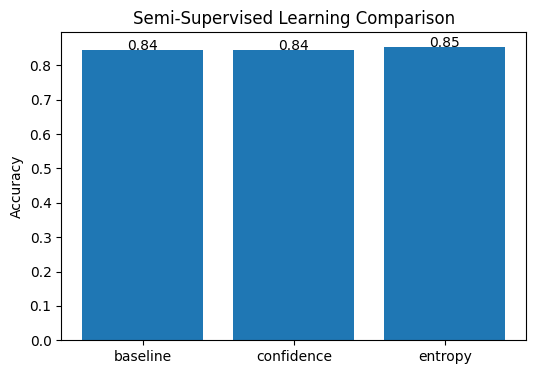

In [12]:
labels = list(results.keys())
values = list(results.values())

plt.figure(figsize=(6,4))
plt.bar(labels, values)

for i, v in enumerate(values):
    plt.text(i, v, f"{v:.2f}", ha='center')

plt.ylabel("Accuracy")
plt.title("Semi-Supervised Learning Comparison")
plt.show()

In [13]:
results = run_semi_supervised_experiment(window_size=21)
print(results)


===== Semi-Supervised (21 days) =====
Baseline Accuracy: 0.8706896551724138
Pseudo-labels (confidence): 89
Pseudo-labels (entropy): 89

Final Comparison:
Baseline: 0.8706896551724138
Confidence Pseudo: 0.8362068965517241
Entropy Pseudo: 0.8448275862068966
{'baseline': 0.8706896551724138, 'confidence': 0.8362068965517241, 'entropy': 0.8448275862068966}
